In [60]:
import pandas as pd
import numpy as np 

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torch.utils.data import DataLoader

from tqdm import tqdm
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import json

import matplotlib.pyplot as plt
%matplotlib inline

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# REMEMBER TO DROP SUBJECTS WITH NAN IN SENSORS

In [61]:
df = pd.read_parquet("Data/dipser_transformed_data.parquet", engine="pyarrow")
df["time_sec"] = df["time"].astype(str).str[:8]
df['subject_experiment_id'] = df['group'] + "_" + df['experiment'] + '_' + df['subject'] 
df.head()

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,opt3007_light_mean,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race,attention,subject_id,time_sec,subject_experiment_id
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
1,group01,10:59:49.147013,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
2,group01,10:59:49.252899,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
3,group01,10:59:49.343618,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01
4,group01,10:59:49.504931,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,69.0,0.0,94.0,male,27.0,white,2.75,group01_subject_01,10:59:49,group01_experiment02_subject_01


In [62]:
df.columns

Index(['group', 'time', 'subject', 'experiment', 'image_path', 'metadata',
       'labeler_02 emotion', 'labeler_02 attention', 'labeler_01 attention',
       'labeler_04 attention', 'labeler_04 emotion', 'labeler_03 emotion',
       'labeler_03 attention', 'labeler_01 emotion', 'self_labeling emotion',
       'self_labeling attention', 'labeler_02 emotionfilled',
       'labeler_02 attentionfilled', 'labeler_01 attentionfilled',
       'labeler_04 attentionfilled', 'labeler_04 emotionfilled',
       'labeler_03 emotionfilled', 'labeler_03 attentionfilled',
       'labeler_01 emotionfilled', 'self_labeling emotionfilled',
       'self_labeling attentionfilled', 'labeler_05 emotion',
       'labeler_05 attention', 'labeler_05 emotionfilled',
       'labeler_05 attentionfilled', 'lsm6dso_gyroscope_mean_x',
       'lsm6dso_gyroscope_std_x', 'lsm6dso_gyroscope_mean_y',
       'lsm6dso_gyroscope_std_y', 'lsm6dso_gyroscope_mean_z',
       'lsm6dso_gyroscope_std_z', 'lsm6dso_gyroscope_mean_ma

In [63]:
df[['attention', 'samsung_hr_none_wakeup_sensor_value']].isna().sum()

attention                                  0
samsung_hr_none_wakeup_sensor_value    17624
dtype: int64

In [64]:
sensor_cols = [
    # Gyroscope
    'lsm6dso_gyroscope_mean_x', 'lsm6dso_gyroscope_std_x',
    'lsm6dso_gyroscope_mean_y', 'lsm6dso_gyroscope_std_y',
    'lsm6dso_gyroscope_mean_z', 'lsm6dso_gyroscope_std_z',
    'lsm6dso_gyroscope_mean_mag', 'lsm6dso_gyroscope_std_mag',

    # Linear acceleration
    'samsung_linear_acceleration_sensor_mean_x',
    'samsung_linear_acceleration_sensor_std_x',
    'samsung_linear_acceleration_sensor_mean_y',
    'samsung_linear_acceleration_sensor_std_y',
    'samsung_linear_acceleration_sensor_mean_z',
    'samsung_linear_acceleration_sensor_std_z',
    'samsung_linear_acceleration_sensor_mean_mag',
    'samsung_linear_acceleration_sensor_std_mag',

    # Rotation
    'samsung_rotation_vector_mean_value0',
    'samsung_rotation_vector_std_value0',
    'samsung_rotation_vector_mean_value1',
    'samsung_rotation_vector_std_value1',
    'samsung_rotation_vector_mean_value2',
    'samsung_rotation_vector_std_value2',
    'samsung_rotation_vector_mean_value3',
    'samsung_rotation_vector_std_value3',

    # Light
    'opt3007_light_mean',
    'opt3007_light_std',

    # Heart rate
    'samsung_hr_none_wakeup_sensor_value'
]

In [65]:
missing_ratio = (
    df.groupby('subject_experiment_id')["samsung_hr_none_wakeup_sensor_value"]
    .apply(lambda x: x.isna().mean())
)
missing_ratio.sort_values(ascending=False).head(11)

subject_experiment_id
group02_experiment06_subject_21    1.000000
group02_experiment07_subject_01    1.000000
group02_experiment02_subject_14    0.901812
group02_experiment03_subject_04    0.848787
group03_experiment07_subject_08    0.828748
group02_experiment06_subject_06    0.796814
group02_experiment02_subject_13    0.638924
group01_experiment07_subject_05    0.549825
group01_experiment07_subject_01    0.415563
group01_experiment07_subject_15    0.381448
group01_experiment03_subject_12    0.099926
Name: samsung_hr_none_wakeup_sensor_value, dtype: float64

In [66]:
len(set(df['subject_experiment_id']))

214

In [67]:
MISSING_SENSORS_THRESHOLD = 0.3

In [68]:
valid_subjects = missing_ratio[missing_ratio < MISSING_SENSORS_THRESHOLD].index
df = df[df["subject_experiment_id"].isin(valid_subjects)]

In [69]:
df[sensor_cols[0:3]].isna().sum()

lsm6dso_gyroscope_mean_x    626
lsm6dso_gyroscope_std_x     626
lsm6dso_gyroscope_mean_y    626
dtype: int64

In [70]:
len(set(df['subject_experiment_id']))

204

In [71]:
missing_sensors = df[df['samsung_hr_none_wakeup_sensor_value'].isna()]
missing_sensors.groupby(['subject_experiment_id']).size()

subject_experiment_id
group01_experiment03_subject_01      2
group01_experiment03_subject_02      2
group01_experiment03_subject_03      4
group01_experiment03_subject_06      8
group01_experiment03_subject_07      6
group01_experiment03_subject_08      4
group01_experiment03_subject_09      1
group01_experiment03_subject_11      1
group01_experiment03_subject_12    270
group01_experiment03_subject_13      7
group01_experiment03_subject_14      4
group01_experiment03_subject_15      3
group01_experiment03_subject_16      5
group01_experiment03_subject_18      6
group01_experiment07_subject_04      6
group01_experiment07_subject_07      2
group01_experiment07_subject_09      1
group01_experiment07_subject_17      7
group01_experiment07_subject_18      6
group02_experiment02_subject_20     50
group03_experiment02_subject_02    111
group03_experiment02_subject_05     70
group03_experiment06_subject_02     44
group03_experiment07_subject_02      2
group03_experiment07_subject_05      2
gro

In [72]:
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())

In [73]:
df[sensor_cols[0:3]].isna().sum()

lsm6dso_gyroscope_mean_x    0
lsm6dso_gyroscope_std_x     0
lsm6dso_gyroscope_mean_y    0
dtype: int64

In [74]:
df[sensor_cols] = df[sensor_cols].astype(np.float32)

In [75]:
# group per second and keep the first row only
df_sec = (
    df.sort_values("time")
      .groupby(["subject_id", "time_sec"])
      .first()
      .reset_index())

In [76]:
class DipserSensorDataset(Dataset):
    def __init__(self, df, sensor_cols):
        self.df = df.reset_index(drop=True)
        self.sensor_cols = sensor_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
    
        x = torch.tensor(
            row[self.sensor_cols].values.astype(np.float32)
        )
        y = torch.tensor(row["attention"], dtype=torch.float32)
    
        return x, y, idx

### Train Test Split

In [77]:
from sklearn.model_selection import train_test_split

subject_df = df_sec[['subject_id', 'gender_name']].drop_duplicates()

train_sub, test_sub = train_test_split(
    subject_df,
    test_size=0.2,
    stratify=subject_df['gender_name'],
    random_state=42
)

train_subjects = train_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sec[df_sec["subject_id"].isin(train_subjects)]
test_df  = df_sec[df_sec["subject_id"].isin(test_subjects)]

### Normalize Sensor Features

In [78]:
scaler = StandardScaler()

train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])

/scratch-local/cfragkiadakis.22245873/ipykernel_1717620/1600883239.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
/scratch-local/cfragkiadakis.22245873/ipykernel_1717620/1600883239.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])


In [79]:
train_dataset = DipserSensorDataset(train_df, sensor_cols)
test_dataset  = DipserSensorDataset(test_df, sensor_cols)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

In [93]:
class SensorModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


In [94]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for x, labels, _ in pbar:
        x, labels = x.to(device), labels.to(device)

        preds = model(x)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [95]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times), np.std(inference_times)

In [96]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None

    def step(self, metric, model):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0
            self.best_model = model.state_dict()
            torch.save(early_stopping.best_model, "sensors_baseline_best.pt")  # save best model
            return False  # continue
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                return True  # stop
            return False

In [97]:
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SensorModel(input_dim=len(sensor_cols)).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [98]:
early_stopping = EarlyStopping(patience=7)
NUM_EPOCHS = 50

train_losses = []
train_mae_list, train_rmse_list, val_mae_list, val_rmse_list = [], [], [], []
best_rmse = None
best_latency = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time, std_time = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")

    if val_mae < early_stopping.best_score:
        best_rmse = val_rmse
        best_latency = avg_time

    stop = early_stopping.step(val_mae, model)

    if stop:
        print("Early stopping triggered")
        break

# load best model
model.load_state_dict(early_stopping.best_model)

best_mae = early_stopping.best_score

results = {
    "mae": best_mae,
    "rmse": best_rmse,
    "latency_per_batch": best_latency,
    "latency_per_sample_ms": (best_latency / train_loader.batch_size) * 1000,
    "epochs_trained": len(train_losses)
}

with open("sensor_results.json", "w") as f:
    json.dump(results, f, indent=4)


Epoch 1
Train Loss: 0.6384
Train MAE: 0.5366 | Train RMSE: 0.7992
Val MAE: 0.3558 | Val RMSE: 0.4775



Epoch 2
Train Loss: 0.1885
Train MAE: 0.3220 | Train RMSE: 0.4342
Val MAE: 0.3428 | Val RMSE: 0.4610



Epoch 3
Train Loss: 0.1651
Train MAE: 0.3051 | Train RMSE: 0.4064
Val MAE: 0.3334 | Val RMSE: 0.4435



Epoch 4
Train Loss: 0.1548
Train MAE: 0.2953 | Train RMSE: 0.3934
Val MAE: 0.3340 | Val RMSE: 0.4438
EarlyStopping counter: 1/7



Epoch 5
Train Loss: 0.1472
Train MAE: 0.2880 | Train RMSE: 0.3836
Val MAE: 0.3312 | Val RMSE: 0.4378


...


Epoch 9
Train Loss: 0.1312
Train MAE: 0.2703 | Train RMSE: 0.3622
Val MAE: 0.3292 | Val RMSE: 0.4324
EarlyStopping counter: 3/7



Epoch 10
Train Loss: 0.1288
Train MAE: 0.2680 | Train RMSE: 0.3589
Val MAE: 0.3317 | Val RMSE: 0.4319
EarlyStopping counter: 4/7



Epoch 11
Train Loss: 0.1272
Train MAE: 0.2663 | Train RMSE: 0.3566
Val MAE: 0.3299 | Val RMSE: 0.4369
EarlyStopping counter: 5/7



Epoch 12
Train Loss: 0.1244
Train MAE: 0.2632 | Train RMSE: 0.3527
Val MAE: 0.3337 | Val RMSE: 0.4444
EarlyStopping counter: 6/7



Epoch 13
Train Loss: 0.1232
Train MAE: 0.2620 | Train RMSE: 0.3510
Val MAE: 0.3362 | Val RMSE: 0.4491
EarlyStopping counter: 7/7
Early stopping triggered


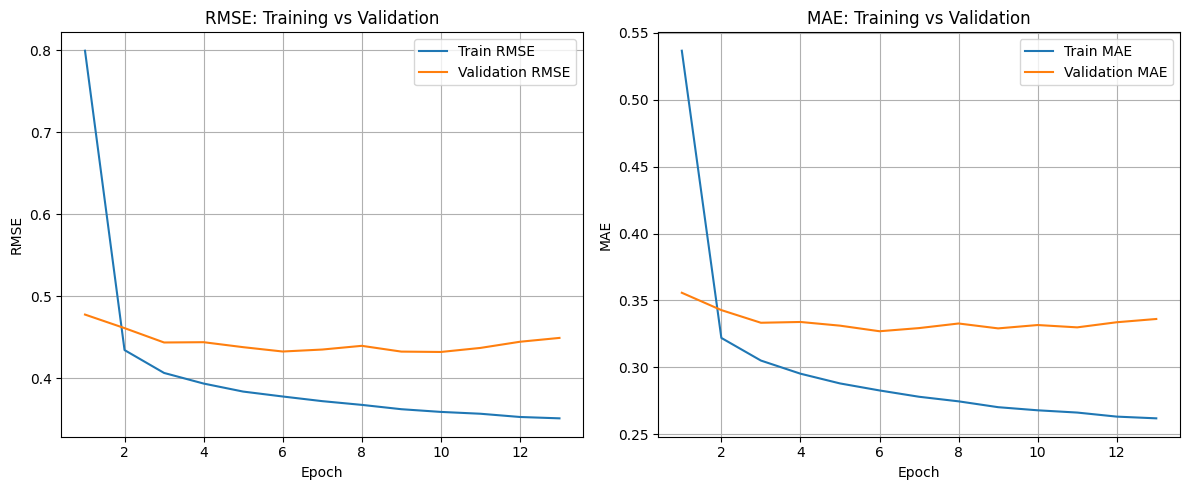

In [99]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig("sensor_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [100]:
batch_size = train_loader.batch_size
latency_per_sample = avg_time / batch_size

print(f"Latency per sample: {latency_per_sample*1000:.2f} ms")

Latency per sample: 0.00 ms


In [101]:
model.load_state_dict(torch.load("sensors_baseline_best.pt"))
model.eval()

def collect_predictions(model, df, loader):
    model.eval()

    results = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Collecting predictions")

        for imgs, labels, idx in pbar:
            imgs = imgs.to(device)

            preds = model(imgs).cpu().numpy()

            for i in range(len(preds)):
                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": preds[i],
                    "true": labels[i].item(),
                    "gender": row["gender_name"],
                    "age": row["age"]
                })

    return pd.DataFrame(results)

/scratch-local/cfragkiadakis.22245873/ipykernel_1717620/1313488753.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("sensors_baseline_bes

In [102]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

In [103]:
results_df = collect_predictions(model, test_df, test_loader)

gender_mae, worst, gap = compute_group_mae(results_df, "gender")

print("MAE per gender:\n", gender_mae)
print(f"\nWorst-group MAE: {worst:.4f}")
print(f"Gap: {gap:.4f}")

MAE per gender:
 gender
female    0.322342
male      0.336817
dtype: float64

Worst-group MAE: 0.3368
Gap: 0.0145



/scratch-local/cfragkiadakis.22245873/ipykernel_1717620/633029479.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(


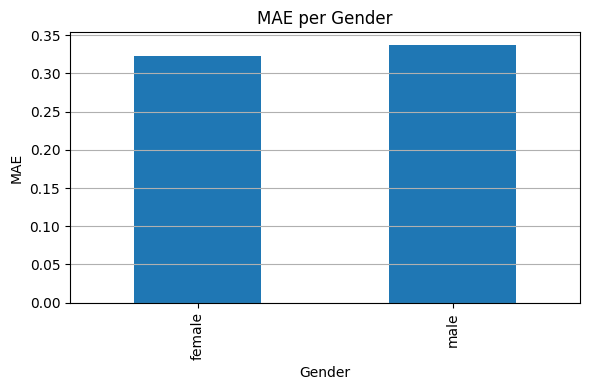

In [104]:
gender_mae.plot(kind="bar", figsize=(6,4))
plt.title("MAE per Gender")
plt.ylabel("MAE")
plt.xlabel("Gender")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("fairness_gender.png", dpi=300)
plt.show()

In [105]:
results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])
age_mae, worst, gap = compute_group_mae(results_df, "age_group")

print("MAE per age:\n", age_mae)
print(f"\nWorst-group MAE: {worst:.4f}")
print(f"Gap: {gap:.4f}")

MAE per age:
 age_group
(13, 17]    0.307981
(17, 20]    0.274341
(20, 22]    0.366449
(22, 26]    0.320610
(26, 44]    0.381086
dtype: float64

Worst-group MAE: 0.3811
Gap: 0.1067


/scratch-local/cfragkiadakis.22245873/ipykernel_1717620/633029479.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.22245873/ipykernel_1717620/633029479.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(
